# Data Cleaning


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import scipy.signal as sps

In [2]:
PARQ_PATH = Path('../sample_dataset/processed_data/parquets/20220730-0002.parquet')
DC_OFFSET = 1.9  # Volts

In [3]:
# Load the parquet file into a DataFrame
df = pd.read_parquet(PARQ_PATH)
df.columns = df.columns.astype('int16') # parquet stores column names as strings; we want integers

num_initial_signals = df.shape[0]
print(f"\x1b[1;36m{num_initial_signals}\x1b[0m signals loaded.")

5000 signals loaded.


In [4]:
# Drop any signals that have missing or infinite values
df = df.replace([np.inf, -np.inf], np.nan).dropna(how='any')
num_missing_signals = num_initial_signals - df.shape[0]
print(f"Removed \x1b[1;31m{num_missing_signals}\x1b[0m signals with missing or infinite values.")

Removed 58 signals with missing or infinite values.


In [5]:
# Subtract DC offset
df = df - DC_OFFSET
# Invert signals
df = -1 * df

In [6]:
# Offset dataframe upwards by global minimum
# TODO: check if this is necessary
df = df + abs(min(df.min()))

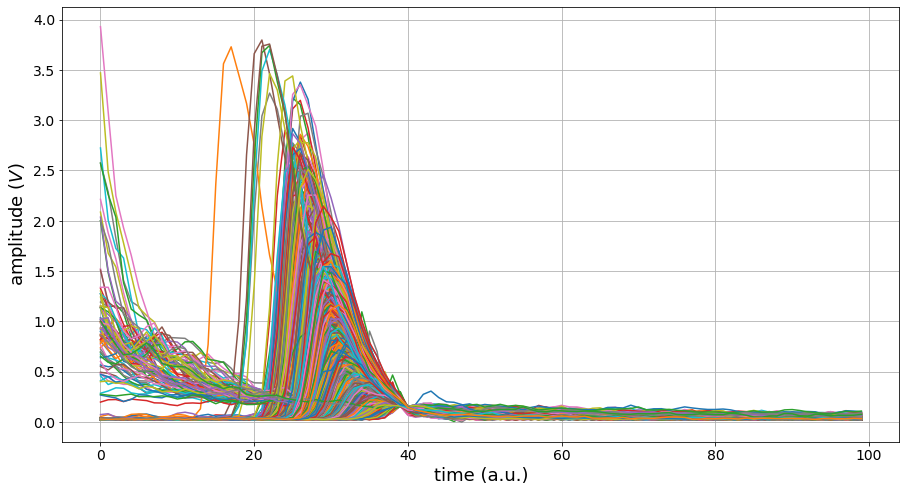

In [7]:
# Plot signals
fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    df.T
)

ax.grid(visible=True)

ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("time (a.u.)", fontsize=18)
ax.set_ylabel("amplitude ($V$)", fontsize=18)

plt.show()

# Cleaning the Data

## Smoothing
Using Savitzky-Golay Filter...

There are a couple required parameters to adjust here. Decide parameters for the algorithm:

- `window_length`: Size of the filter window
- `polyorder`: Order of the polynomial to fit the data

In [8]:
window_length = 10
polyorder = 3

In [9]:
df_smooth = df.T.apply(
    sps.savgol_filter, args=(window_length, polyorder)
)

## Filtering
To filter the data we are looking for, we are just using a `find_peaks` algorithm and adjust the `prominence` threshold to determine the selected data.

In [30]:
def find_peaks(series, prominence=0.1):
    peaks, amplitudes = sps.find_peaks(series, prominence=prominence)
    return peaks, amplitudes['prominences']

# Get peaks and amplitudes
packed_vals = df_smooth.apply(find_peaks)
peaks, amplitudes = packed_vals.iloc[0,:], packed_vals.iloc[1,:]

# Drop signals that did not make the cut
to_drop = [*peaks[peaks.apply(len) == 0 ].index]
df_smooth_filtered = df_smooth.drop(to_drop, axis=1)
amplitudes = amplitudes.drop(to_drop)

num_missing_signals = num_initial_signals - df_smooth_filtered.shape[1]
print(f"Removed \x1b[1;31m{num_missing_signals}\x1b[0m signals assumed to be bad.")

Removed 147 signals assumed to be bad.


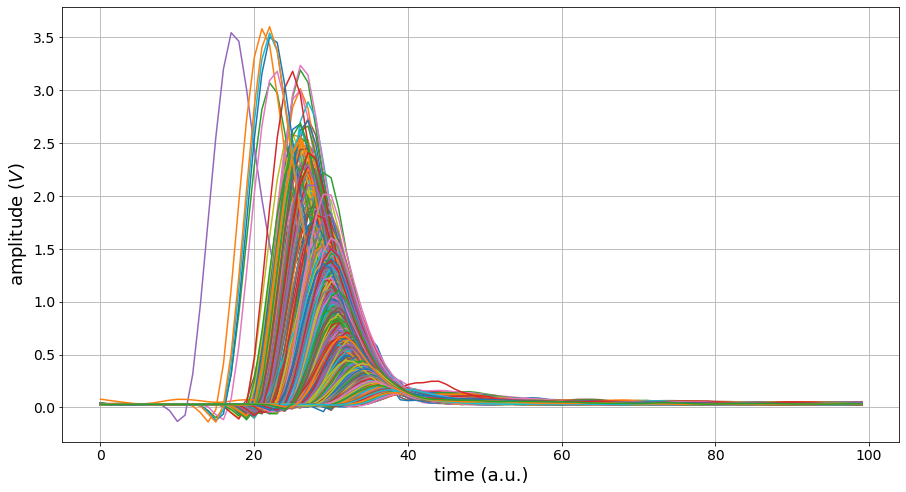

In [31]:
fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    df_smooth_filtered
)

ax.grid(visible=True)

ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("time (a.u.)", fontsize=18)
ax.set_ylabel("amplitude ($V$)", fontsize=18)

plt.show()

# Processing
Now we process the data to get the integrals.

In [13]:
offset = 5
tail_indices = peaks + offset

def sum_tail(series, tail_indices = tail_indices):
    tail_idx = tail_indices[series.name]
    return series.iloc[tail_idx[0]:-1].sum()

total_integrals = df_smooth_filtered.sum()
tail_integrals = df_smooth_filtered.apply(sum_tail)
quotients = tail_integrals / total_integrals

In [18]:
quotients

b0002s0001    0.477435
b0002s0002    0.475155
b0002s0003    0.331816
b0002s0004    0.393665
b0002s0005    0.454707
                ...   
b0002s4996    0.415413
b0002s4997    0.462173
b0002s4998    0.347693
b0002s4999    0.371459
b0002s5000    0.331745
Length: 4853, dtype: float32

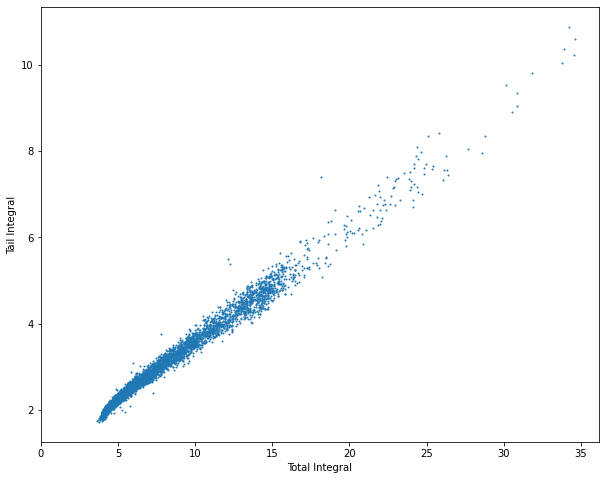

In [32]:
fig, ax = plt.subplots(figsize=(10,8))

ax.plot(total_integrals, tail_integrals, 'o', markersize=1)
plt.xlabel('Total Integral')
plt.ylabel('Tail Integral')
plt.xlim(0)
plt.show()

# Time Analysis

In [33]:
%%timeit

# Smoothing
window_length = 10
polyorder = 3
df_smooth = df.T.apply(
    sps.savgol_filter, args=(window_length, polyorder)
)


# Filtering
def find_peaks(series, prominence=0.1):
    peaks, amplitudes = sps.find_peaks(series, prominence=prominence)
    return peaks, amplitudes['prominences']

# Get peaks and amplitudes
packed_vals = df_smooth.apply(find_peaks)
peaks, amplitudes = packed_vals.iloc[0,:], packed_vals.iloc[1,:]

# Drop signals that did not make the cut
to_drop = [*peaks[peaks.apply(len) == 0 ].index]
df_smooth_filtered = df_smooth.drop(to_drop, axis=1)
amplitudes = amplitudes.drop(to_drop)


# Integration
offset = 5
tail_indices = peaks + offset

def sum_tail(series, tail_indices = tail_indices):
    tail_idx = tail_indices[series.name]
    return series.iloc[tail_idx[0]:-1].sum()

total_integrals = df_smooth_filtered.sum()
tail_integrals = df_smooth_filtered.apply(sum_tail)
quotients = tail_integrals / total_integrals

4.15 s ± 562 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
